In [1]:
!pip install -q --upgrade pip
!pip install -q pandas numpy matplotlib pyarrow lightgbm scikit-learn shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 44.9 MB/s eta 0:00:00


In [2]:
import json
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount("/content/drive")
DRIVE_DIR = "/content/drive/MyDrive/energy-forecast"

feat = pd.read_parquet(f"{DRIVE_DIR}/features_hourly.parquet")
gbm = lgb.Booster(model_file=f"{DRIVE_DIR}/lightgbm_demand.txt")
with open(f"{DRIVE_DIR}/phase3_results.json") as f:
    phase3_results = json.load(f)

FEATURES = [
    "hour_of_day", "dow", "month", "is_weekend", "is_holiday",
    "lag_1", "lag_2", "lag_3", "lag_24", "lag_48", "lag_72", "lag_168",
    "roll_24_mean", "roll_24_std", "roll_168_mean",
    "temperature", "apparentTemperature", "humidity", "windSpeed",
]

train = feat[feat["hour"] < "2013-11-01"]
val = feat[(feat["hour"] >= "2013-11-01") & (feat["hour"] < "2014-01-01")]
test = feat[feat["hour"] >= "2014-01-01"].copy()
print(f"test: {len(test):,} rows")

Mounted at /content/drive
test: 1,393 rows


In [3]:
test["pred"] = gbm.predict(test[FEATURES], num_iteration=gbm.best_iteration)
test["err"] = test["pred"] - test["demand"]
test["abs_err"] = test["err"].abs()
test["demand_bucket"] = pd.qcut(test["demand"], q=4, labels=["Q1 low", "Q2", "Q3", "Q4 peak"])

print(f"Overall MAE {test['abs_err'].mean():.4f}")
print(f"Mean signed error (bias): {test['err'].mean():+.4f}  (negative = underestimation)")

Overall MAE 0.0111
Mean signed error (bias): +0.0009  (negative = underestimation)


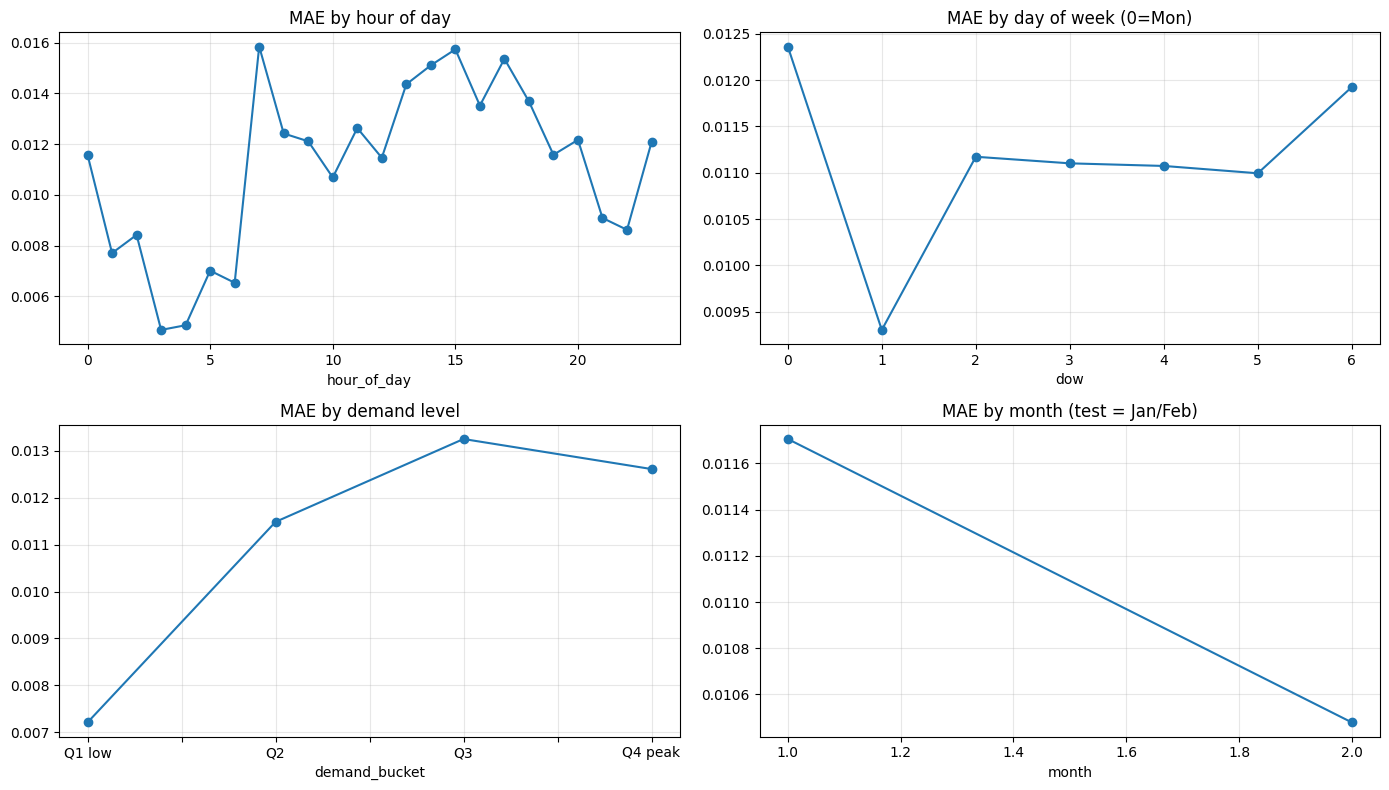

weekend   MAE 0.0115  (n=384)
weekday   MAE 0.0110  (n=1009)
holiday   MAE 0.0262  (n=24)


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

test.groupby("hour_of_day")["abs_err"].mean().plot(ax=axes[0, 0], marker="o", title="MAE by hour of day")
test.groupby("dow")["abs_err"].mean().plot(ax=axes[0, 1], marker="o", title="MAE by day of week (0=Mon)")
test.groupby("demand_bucket", observed=True)["abs_err"].mean().plot(ax=axes[1, 0], marker="o", title="MAE by demand level")
test.groupby("month")["abs_err"].mean().plot(ax=axes[1, 1], marker="o", title="MAE by month (test = Jan/Feb)")

for ax in axes.flat:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for label, mask in [("weekend", test["is_weekend"] == 1), ("weekday", test["is_weekend"] == 0), ("holiday", test["is_holiday"] == 1)]:
    print(f"{label:9s} MAE {test.loc[mask, 'abs_err'].mean():.4f}  (n={int(mask.sum())})")

In [5]:
p95 = test["demand"].quantile(0.95)
peaks = test[test["demand"] >= p95]
normal = test[test["demand"] < p95]

print(f"Peak threshold (p95): {p95:.3f} kWh | peak hours in test: {len(peaks)}")
print(f"Normal hours:  MAE {normal['abs_err'].mean():.4f} | bias {normal['err'].mean():+.4f}")
print(f"Peak hours:    MAE {peaks['abs_err'].mean():.4f} | bias {peaks['err'].mean():+.4f}")
print()
print("Interpretation: negative peak bias = the model underestimates demand spikes,")
print("the classic regression-to-the-mean behavior of tree models.")

Peak threshold (p95): 0.761 kWh | peak hours in test: 70
Normal hours:  MAE 0.0111 | bias +0.0007
Peak hours:    MAE 0.0112 | bias +0.0040

Interpretation: negative peak bias = the model underestimates demand spikes,
the classic regression-to-the-mean behavior of tree models.


In [6]:
worst = test.nlargest(10, "abs_err")[
            ["hour", "demand", "pred", "abs_err", "hour_of_day", "dow", "is_holiday", "temperature"]
        ]
worst

,hour,demand,pred,abs_err,hour_of_day,dow,is_holiday,temperature
9982,2014-02-28 00:00:00+00:00,0.218075,0.410070,0.191995,0,4,0,3.81
8591,2014-01-01 01:00:00+00:00,0.458727,0.388017,0.07071,1,2,1,6.90
8590,2014-01-01 00:00:00+00:00,0.525989,0.461328,0.064661,0,2,1,7.76
8717,2014-01-06 07:00:00+00:00,0.417837,0.357761,0.060077,7,0,0,11.48
8602,2014-01-01 12:00:00+00:00,0.602627,0.543262,0.059365,12,2,1,8.24
9661,2014-02-14 15:00:00+00:00,0.535467,0.477681,0.057786,15,4,0,7.96
8592,2014-01-01 02:00:00+00:00,0.37596,0.318781,0.057178,2,2,1,6.59
8627,2014-01-02 13:00:00+00:00,0.456,0.511926,0.055926,13,3,0,9.95
8651,2014-01-03 13:00:00+00:00,0.541165,0.485892,0.055273,13,4,0,8.96
8616,2014-01-02 02:00:00+00:00,0.298122,0.353120,0.054998,2,3,0,9.23


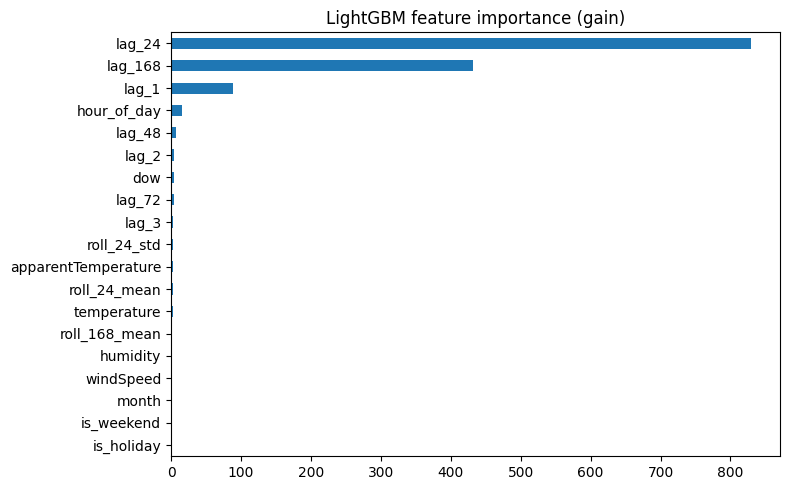

In [7]:
imp = pd.Series(gbm.feature_importance(importance_type="gain"), index=FEATURES).sort_values()
imp.plot.barh(figsize=(8, 5), title="LightGBM feature importance (gain)")
plt.tight_layout()
plt.show()

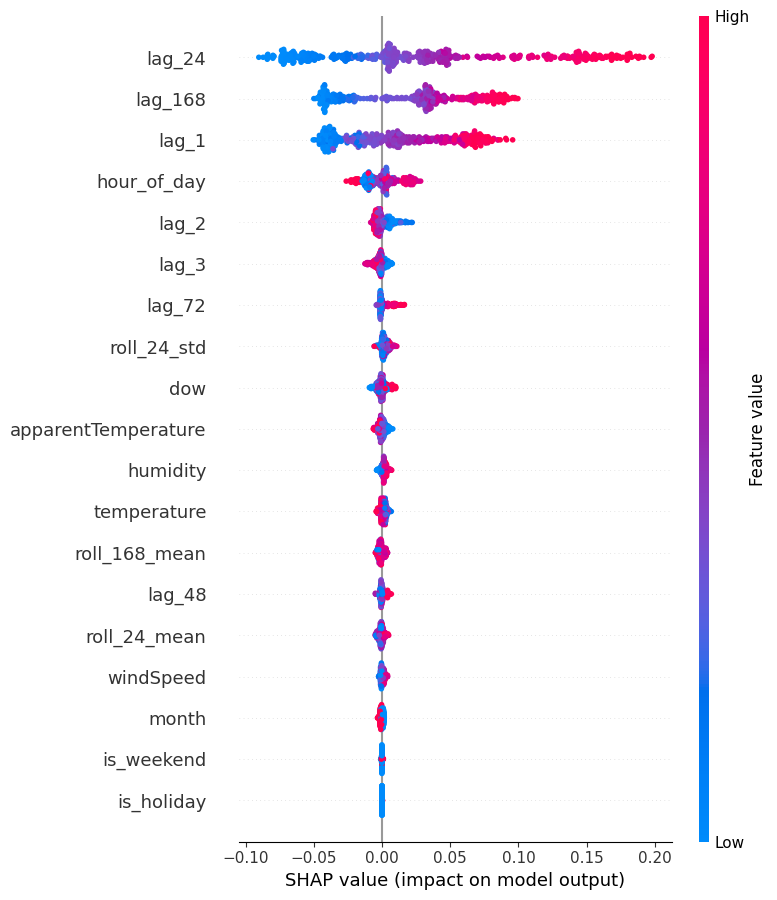

In [8]:
import shap

explainer = shap.TreeExplainer(gbm)
sample = test[FEATURES].sample(500, random_state=42)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample, show=True)

In [9]:
def train_quantile(alpha: float) -> lgb.Booster:
    params = {
        "objective": "quantile",
        "alpha": alpha,
        "metric": "quantile",
        "learning_rate": 0.05,
        "num_leaves": 63,
        "min_data_in_leaf": 50,
        "feature_fraction": 0.9,
        "bagging_fraction": 0.9,
        "bagging_freq": 1,
        "seed": 42,
        "verbose": -1,
    }
    dtrain = lgb.Dataset(train[FEATURES], label=train["demand"])
    dval = lgb.Dataset(val[FEATURES], label=val["demand"], reference=dtrain)
    return lgb.train(
        params, dtrain, num_boost_round=3000,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(100, verbose=False)],
    )

q10 = train_quantile(0.1)
q50 = train_quantile(0.5)
q90 = train_quantile(0.9)

test["p10"] = q10.predict(test[FEATURES], num_iteration=q10.best_iteration)
test["p50"] = q50.predict(test[FEATURES], num_iteration=q50.best_iteration)
test["p90"] = q90.predict(test[FEATURES], num_iteration=q90.best_iteration)
print("Quantile models trained")

Quantile models trained


In [10]:
covered = (test["demand"] >= test["p10"]) & (test["demand"] <= test["p90"])
width = test["p90"] - test["p10"]

print(f"Nominal coverage: 80.0%")
print(f"Empirical coverage: {covered.mean():.1%}")
print(f"Mean interval width: {width.mean():.4f} kWh")
print()
print(f"Coverage on peak hours (p95+): {covered[test['demand'] >= p95].mean():.1%}")
print(f"Coverage on normal hours:      {covered[test['demand'] < p95].mean():.1%}")

crossings = int((test["p10"] > test["p90"]).sum())
print(f"Quantile crossings (p10 > p90, should be ~0): {crossings}")

Nominal coverage: 80.0%
Empirical coverage: 64.3%
Mean interval width: 0.0358 kWh

Coverage on peak hours (p95+): 77.1%
Coverage on normal hours:      63.6%
Quantile crossings (p10 > p90, should be ~0): 6


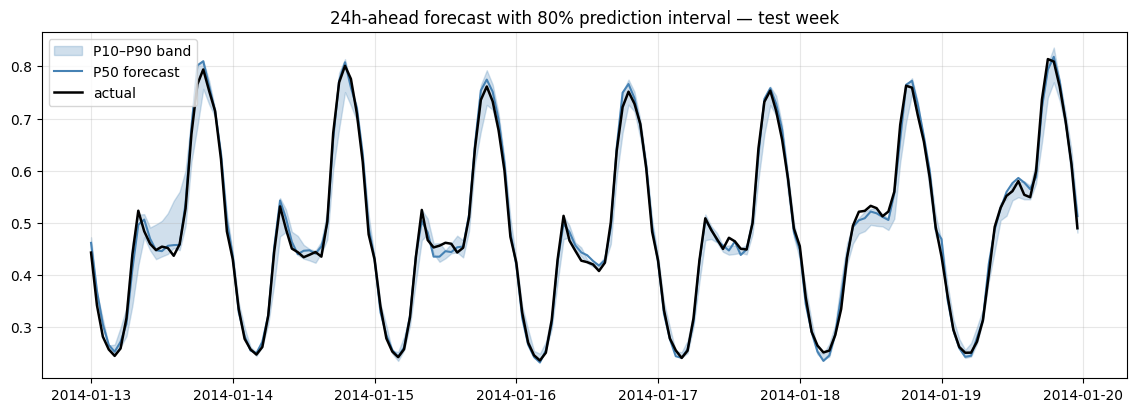

In [11]:
week = test[(test["hour"] >= "2014-01-13") & (test["hour"] < "2014-01-20")]
plt.figure(figsize=(14, 4.5))
plt.fill_between(week["hour"], week["p10"], week["p90"], alpha=0.25, label="P10–P90 band", color="steelblue")
plt.plot(week["hour"], week["p50"], label="P50 forecast", color="steelblue")
plt.plot(week["hour"], week["demand"], label="actual", color="black", lw=1.8)
plt.legend()
plt.title("24h-ahead forecast with 80% prediction interval — test week")
plt.grid(alpha=0.3)
plt.show()

In [12]:
q10.save_model(f"{DRIVE_DIR}/lightgbm_q10.txt")
q50.save_model(f"{DRIVE_DIR}/lightgbm_q50.txt")
q90.save_model(f"{DRIVE_DIR}/lightgbm_q90.txt")

phase4 = {
    "error_analysis": {
        "overall_mae": float(test["abs_err"].mean()),
        "bias": float(test["err"].mean()),
        "peak_mae": float(peaks["abs_err"].mean()),
        "peak_bias": float(peaks["err"].mean()),
        "normal_mae": float(normal["abs_err"].mean()),
        "weekend_mae": float(test.loc[test["is_weekend"] == 1, "abs_err"].mean()),
        "weekday_mae": float(test.loc[test["is_weekend"] == 0, "abs_err"].mean()),
    },
    "intervals": {
        "nominal_coverage": 0.80,
        "empirical_coverage": float(covered.mean()),
        "mean_width_kwh": float(width.mean()),
        "peak_coverage": float(covered[test["demand"] >= p95].mean()),
    },
}
with open(f"{DRIVE_DIR}/phase4_results.json", "w") as f:
    json.dump(phase4, f, indent=2)
print(json.dumps(phase4, indent=2))

{
  "error_analysis": {
    "overall_mae": 0.011133983322526846,
    "bias": 0.000874973564715536,
    "peak_mae": 0.011159175024685117,
    "peak_bias": 0.00395761990673647,
    "normal_mae": 0.011132650428232757,
    "weekend_mae": 0.011460338716246285,
    "weekday_mae": 0.011009780675164841
  },
  "intervals": {
    "nominal_coverage": 0.8,
    "empirical_coverage": 0.6432160804020101,
    "mean_width_kwh": 0.03578679341053267,
    "peak_coverage": 0.7714285714285715
  }
}


In [13]:
val = val.copy()
val["p50"] = q50.predict(val[FEATURES], num_iteration=q50.best_iteration)
resid = val["demand"] - val["p50"]
lo, hi = np.quantile(resid, [0.1, 0.9])
print(f"Conformal offsets from validation: lo={lo:+.4f}, hi={hi:+.4f} kWh")

test["cp_lo"] = test["p50"] + lo
test["cp_hi"] = test["p50"] + hi
cp_cov = (test["demand"] >= test["cp_lo"]) & (test["demand"] <= test["cp_hi"])
cp_width = test["cp_hi"] - test["cp_lo"]

print(f"\n{'method':<24}{'coverage':>10}{'width (kWh)':>14}")
print(f"{'raw quantile P10-P90':<24}{covered.mean():>9.1%}{width.mean():>14.4f}")
print(f"{'split-conformal 80%':<24}{cp_cov.mean():>9.1%}{cp_width.mean():>14.4f}")
print(f"\nConformal peak coverage (p95+): {cp_cov[test['demand'] >= p95].mean():.1%}")

Conformal offsets from validation: lo=-0.0204, hi=+0.0177 kWh

method                    coverage   width (kWh)
raw quantile P10-P90        64.3%        0.0358
split-conformal 80%         83.1%        0.0380

Conformal peak coverage (p95+): 80.0%


In [14]:
phase4["intervals"].update({
    "conformal_offsets_kwh": {"lo": float(lo), "hi": float(hi)},
    "conformal_coverage": float(cp_cov.mean()),
    "conformal_width_kwh": float(cp_width.mean()),
    "conformal_peak_coverage": float(cp_cov[test["demand"] >= p95].mean()),
})
phase4["error_analysis"]["holiday_mae"] = float(test.loc[test["is_holiday"] == 1, "abs_err"].mean())
with open(f"{DRIVE_DIR}/phase4_results.json", "w") as fh:
    json.dump(phase4, fh, indent=2)
print("updated phase4_results.json")

updated phase4_results.json
